# 📊 Sales Demand Forecasting Model

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## LOAD DATA

In [3]:
df = pd.read_csv(r"C:\Users\sohai\OneDrive\Desktop\Rehmat\Intership\Case Study B\Case Study B\Case Study B.csv")

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10263.0$,34.0$,58.75$,6.0,1997.50,6/28/2004 0:00,Shipped,2.0,6.0,2004.0,...,25593 South Bay Ln.,NaN,Bridgewater,CT,97562,usa,NaN,King,Julie,Small
1,10310.0,49.0,81.4,11.0,3988.60,10/16/2004 0:00,Shipped,4.0,10.0,2004.0,...,Mehrheimerstr. 369,NaN,Koln,NaN,50739,Germany,EMEA,Pfalzheim,Henriette,Medium
2,10109.0,46.0,100.0,5.0,8257.00,3/10/2003 0:00,Shipped,1.0,3.0,2003.0,...,11328 Douglas Av.,NaN,Philadelphia,PA,71270,usa,NaN,Hernandez,Rosa,Large
3,10292.0,35.0,55.07,1.0,1927.45,9/8/2004 0:00,Shipped,3.0,9.0,2004.0,...,897 Long Airport Avenue,NaN,???,NY,10022,USA,NaN,Yu,Kwai,Small
4,10104.0,44.0,39.6,10.0,1742.40,1/31/2003 0:00,Shipped,1.0,1.0,2003.0,...,"C/ Moralzarzal, 86",NaN,???,NaN,28034,Spain,EMEA,Freyre,Diego,Small


## DATA CLEANING

Handle Null Values

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
# Check missing values
print(df.isnull().sum())

# Fill numeric columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill remaining (categorical/date) using forward fill
df.fillna(method='ffill', inplace=True)

ORDERNUMBER          273
QUANTITYORDERED      273
PRICEEACH            273
ORDERLINENUMBER        0
SALES                  0
ORDERDATE            310
STATUS               310
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE          310
MSRP                   0
PRODUCTCODE          310
CUSTOMERNAME         310
PHONE                310
ADDRESSLINE1         310
ADDRESSLINE2        2807
CITY                 277
STATE               1772
POSTALCODE           383
COUNTRY              210
TERRITORY           1381
CONTACTLASTNAME      310
CONTACTFIRSTNAME     310
DEALSIZE             310
dtype: int64


C:\Users\sohai\AppData\Local\Temp\ipykernel_19120\3809839669.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Handle Duplicates

In [6]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df = df.drop_duplicates()

Duplicate Rows: 25


Fix Data Types

In [7]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

Standardize Categorical Values

In [8]:
df['STATUS'] = df['STATUS'].str.upper().str.strip()

Outlier Treatment

In [9]:
Q1 = df['SALES'].quantile(0.25)
Q3 = df['SALES'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['SALES'] >= lower) & (df['SALES'] <= upper)]

## FEATURE ENGINEERING


In [10]:
df['Year'] = df['ORDERDATE'].dt.year
df['Month'] = df['ORDERDATE'].dt.month
df['Day'] = df['ORDERDATE'].dt.day

## VISUALIZATION 📊

C:\Users\sohai\AppData\Local\Temp\ipykernel_19120\1406274140.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sohai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sohai\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


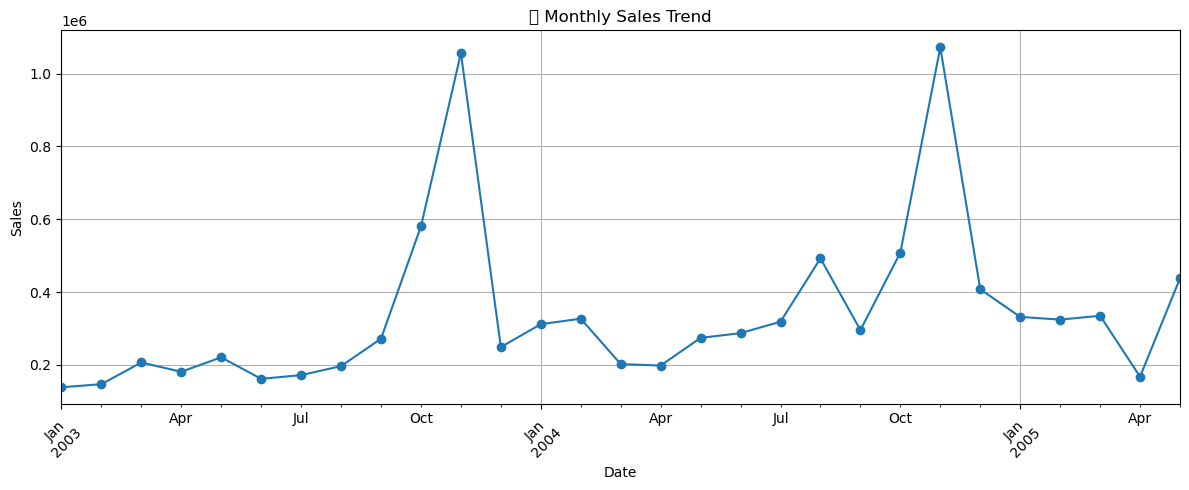

In [11]:
monthly_sales = df.groupby(df['ORDERDATE'].dt.to_period("M"))['SALES'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title("📊 Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## PREPARE DATA FOR MODEL

In [28]:
X = df[['Year', 'Month', 'Day']]
y = df['SALES']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## TRAIN MODEL

In [29]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## PREDICTION

In [14]:
y_pred = model.predict(X_test)

## CONVERT TO CLASSIFICATION (FOR METRICS)

In [15]:
threshold = y.mean()

y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred > threshold).astype(int)

## MODEL EVALUATION 📊

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("Precision:", precision_score(y_test_class, y_pred_class))
print("Recall:", recall_score(y_test_class, y_pred_class))
print("F1 Score:", f1_score(y_test_class, y_pred_class))

Accuracy: 0.46037099494097805
Precision: 0.48484848484848486
Recall: 0.41025641025641024
F1 Score: 0.4444444444444444


ACTUAL VS PREDICTED

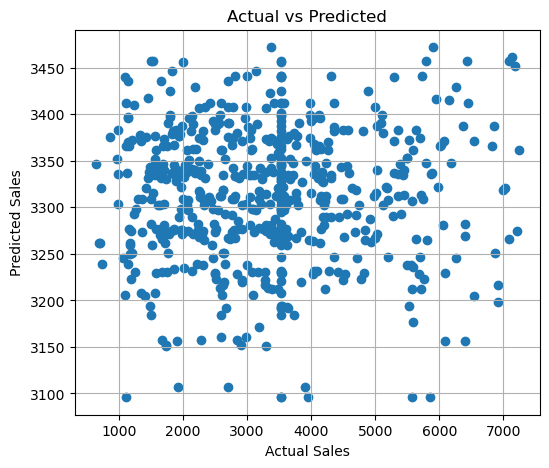

In [30]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.grid(True)
plt.show()

## FUTURE PREDICTION


In [38]:
# Step 1: Create future data (same structure as training)
future_data = pd.DataFrame({
    'Year':[2026, 2026 ,2026, 2026, 2026],
    'Months':[1,1,1,1,1]
    'Days':[1,5,10,15,20]
        })                        

# Step 2: Predict
future_predictions = model.predict(future_data)

# Step 3: Plot
plt.figure(figsize=(8,4))
plt.plot(future_predictions, marker='o')

plt.title("📈 Future Sales Predictions")
plt.xlabel("Prediction Index")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2975063384.py, line 4)